## Is it a tree leaf?

*Based on the fastai tutorial 'Is it a bird?' — adapted as an exercise to recognise 16 tree species common in Northern Germany by their leaves and needles.*

**Changes made:**
- Search terms: `'bird/forest'` → 16 tree species with leaves/needles
- CPU mode enabled (MPS/macOS compatibility fix)
- GradScaler import fix for PyTorch 2.2
- Folder structure adapted
- Model is exported at the end

In [1]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")


In [2]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'


In 2015 the idea of creating a computer system that could recognise tree species from leaf photos was considered extremely challenging.

But today, we can do exactly that, in just a few minutes, using entirely free resources!

The basic steps we'll take are:

1. Use DuckDuckGo to search for images of tree leaves
1. Download ~200 images per species into separate folders
1. Fine-tune a pretrained neural network to recognise 16 species
1. Try running this model on a leaf photo and see if it works.

## Step 1: Download images of tree leaves

In [3]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json


In [4]:
import certifi, os
os.environ['SSL_CERT_FILE'] = certifi.where()


Let's start by searching for an oak leaf photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [5]:
#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('eiche blatt', max_images=1)
urls[0]


'https://media.istockphoto.com/photos/green-oak-leaf-picture-id1078043436?k=6&m=1078043436&s=612x612&w=0&h=dDuj_eGbW2ZLbVwxI0njOgU2FL0RajzesuHuZMXhsZM='

...and then download a URL and take a look at it:

Skipped: HTTP Error 403: Forbidden
Downloaded: https://www.gartenjournal.net/wp-content/uploads/eiche-blaet


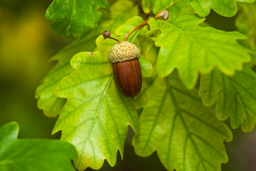

In [6]:
from pathlib import Path
import urllib.request

dest = 'eiche_blatt.jpg'

#NB: Some sites block direct downloads. We try multiple URLs with a browser header.
headers = {'User-Agent': 'Mozilla/5.0'}
for url in search_images('eiche blatt', max_images=10):
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as r, open(dest, 'wb') as f:
            f.write(r.read())
        print(f'Downloaded: {url[:60]}')
        break
    except Exception as e:
        print(f'Skipped: {e}')
        continue

# CPU-only mode — MPS backend requires macOS 12.3+
import torch
from fastai.vision.all import *
defaults.device = torch.device('cpu')

im = Image.open(dest)
im.to_thumb(256,256)


Now let's do the same with a needle photo:

Downloaded: https://live.staticflickr.com/5448/7067451777_264fa8a1f1.jpg


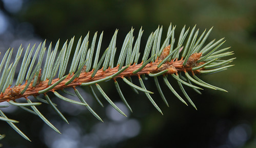

In [9]:
from pathlib import Path
import urllib.request

dest = 'fichte_nadel.jpg'

#NB: Some sites block direct downloads. We try multiple URLs with a browser header.
headers = {'User-Agent': 'Mozilla/5.0'}
for url in search_images('fichte_nadel', max_images=10):
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as r, open(dest, 'wb') as f:
            f.write(r.read())
        print(f'Downloaded: {url[:60]}')
        break
    except Exception as e:
        print(f'Skipped: {e}')
        continue

# CPU-only mode — MPS backend requires macOS 12.3+
import torch
from fastai.vision.all import *
defaults.device = torch.device('cpu')

im = Image.open(dest)
im.to_thumb(256,256)

Our searches seem to be giving reasonable results, so let's grab a few examples of each of our 16 tree species and save each group of photos to a different folder:

In [8]:
searches = [
    'eiche blatt',        # Stieleiche
    'birke blatt',        # Sandbirke
    'buche blatt',        # Rotbuche
    'ahorn blatt',        # Spitzahorn
    'linde blatt',        # Winterlinde
    'esche blatt',        # Gemeine Esche
    'erle blatt',         # Schwarzerle
    'hainbuche blatt',    # Hainbuche
    'pappel blatt',       # Zitterpappel
    'weide blatt',        # Silberweide
    'rosskastanie blatt', # Rosskastanie
    'vogelbeere blatt',   # Eberesche
    'robinie blatt',      # Robinie
    'fichte nadel',       # Gemeine Fichte
    'kiefer nadel',       # Waldkiefer
    'laerche nadel',      # Europäische Lärche
]
path = Path('baumarten_blaetter')

for o in searches:
    dest = (path/o.replace(' ','_'))
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o.replace(' ','_'), max_size=400, dest=path/o.replace(' ','_'))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [10]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)


1

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

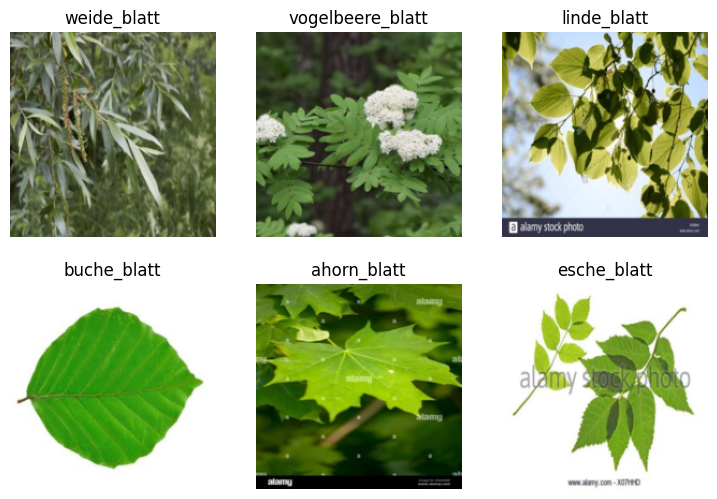

In [11]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)


Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, the tree species name).

    get_items=get_image_files,

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *eiche_blatt*, *birke_blatt*, etc.).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [12]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)


epoch,train_loss,valid_loss,error_rate,time
0,3.499446,1.618777,0.515837,01:42


epoch,train_loss,valid_loss,error_rate,time
0,1.506565,1.275332,0.389140,01:52
1,1.014562,1.241011,0.343891,01:52
2,0.681925,1.238274,0.343891,01:57


Generally when I run this I see over 90% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, a widely-used computer vision dataset with images covering 1000 categories. For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Use our model

Let's see what our model thinks about that oak leaf we downloaded at the start:

In [13]:
baum,_,probs = learn.predict(PILImage.create('eiche_blatt.jpg'))
print(f"This is a: {baum}.")
print(f"Probability it's an oak: {probs.max():.4f}")


This is a: eiche_blatt.
Probability it's an oak: 0.9995


So, as you see, in the space of a few years, creating computer vision classification models has gone from extremely difficult to trivially easy and free!

The same principle is used by professional apps like PlantNet and Google Lens — just with more data and a GPU.

In [14]:
learn.export('baumarten_blaetter_modell.pkl')
print('Model saved!')


Model saved!
